In [38]:
# Imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, FunctionTransformer           
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
import joblib

## Loading Processed Datasets

In [ ]:
X_train = pd.read_parquet('../data/processed/X_train_processed.parquet', engine='fastparquet')
y_train = pd.read_parquet('../data/processed/y_train.parquet', engine='fastparquet').squeeze()
X_test = pd.read_parquet('../data/processed/X_test_processed.parquet', engine='fastparquet')
y_test = pd.read_parquet('../data/processed/y_test.parquet', engine='fastparquet').squeeze()


In [7]:
len(X_train)

3999998

## Inspecting Class Imbalance

In [8]:
y_train.value_counts()

is_fraud
False    3856356
True      143642
Name: count, dtype: int64

In [9]:
y_train.value_counts(normalize=True)

is_fraud
False    0.964089
True     0.035911
Name: proportion, dtype: float64

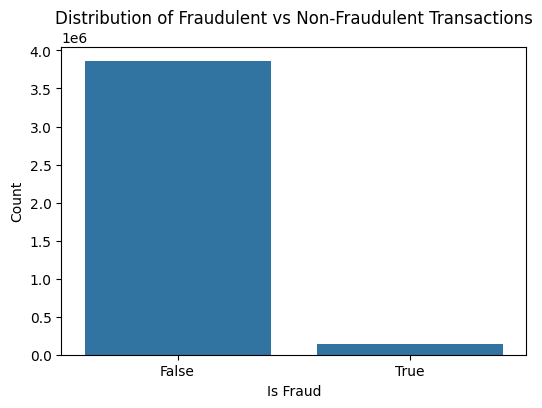

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data= y_train.reset_index())
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.show()

As observed in the previous notebooks and confirmed here, the target variable exhibits a severe class imbalance: approximately 96% of transactions are non-fraudulent, while only 4% are fraudulent.  

This imbalance necessitates careful handling, as the most informative metrics in this context are **recall** and **precision**, rather than overall accuracy. In particular, **recall** is critical in fraud detection, since the primary goal is to minimize false negatives, even if some false positives are allowed.  

For now, we first train several baseline models **without any special class imbalance techniques** to evaluate their raw performance. Subsequently, we will explore techniques such as **oversampling, undersampling, and class-weight adjustments** to improve model performance on the minority class.

## Baseline Model Training and Evaluation

We will train several baseline models using a pipeline consisting of a **StandardScaler** for numeric columns and **one-hot encoding** for categorical variables. This approach is justified for the following reasons:

- **Low cardinality:** Each categorical feature contains approximately 4–8 categories with a relatively balanced distribution, making one-hot encoding well-suited.  
- **No ordinal relationship:** The categories do not have an inherent order (e.g., `transaction_type`, `location`), so encoding methods that impose numerical ranking, such as label encoding, could introduce misleading relationships.  
- **No need for advanced encoding techniques:** Methods like target encoding or frequency encoding are unnecessary, as they are mainly beneficial for high-cardinality features.  

Overall, one-hot encoding provides a simple and effective representation for these categorical variables without introducing unintended bias.

As baseline models, we will use **Logistic Regression**, **Random Forest**, **Extra Trees**, and **XGBoost**. We exclude **SVM**, as it generally performs poorly on datasets containing millions of entries.

In [11]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 3999998 entries, 1867199 to 2779601
Data columns (total 28 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   transaction_type                     str    
 1   merchant_category                    str    
 2   location                             str    
 3   device_used                          str    
 4   time_since_last_transaction          float64
 5   spending_deviation_score             float64
 6   velocity_score                       int64  
 7   geo_anomaly_score                    float64
 8   payment_channel                      str    
 9   time_since_last_transaction_missing  int64  
 10  hour_of_day                          int32  
 11  at_night                             int64  
 12  weekday                              int32  
 13  on_weekend                           int64  
 14  log_amount                           float64
 15  high_amount_and_velocity             int64

In [12]:
categorical_cols = X_train.select_dtypes(include=['string', 'object']).columns.tolist()

In [13]:
categorical_cols 

['transaction_type',
 'merchant_category',
 'location',
 'device_used',
 'payment_channel']

In [14]:
# numerical features excluding binary features
true_numerical_cols = ["time_since_last_transaction", "spending_deviation_score", "velocity_score", "geo_anomaly_score", "hour_of_day", "weekday", "log_amount", "avg_transaction_amount_per_sender", "unique_receivers_per_sender", "accounts_per_device", "transactions_per_ip" ]


In [15]:
true_numerical_cols 

['time_since_last_transaction',
 'spending_deviation_score',
 'velocity_score',
 'geo_anomaly_score',
 'hour_of_day',
 'weekday',
 'log_amount',
 'avg_transaction_amount_per_sender',
 'unique_receivers_per_sender',
 'accounts_per_device',
 'transactions_per_ip']

In [16]:
preprocessing_without_scaling = ColumnTransformer([
     ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
], remainder='passthrough')

In [17]:
categorical_cols

['transaction_type',
 'merchant_category',
 'location',
 'device_used',
 'payment_channel']

In [18]:
preprocessing = ColumnTransformer([
     ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
     ('num', StandardScaler(), true_numerical_cols)
], remainder='passthrough')


### Logistic Regression

We begin with training the **Logistic Regression** model. This model requires feature scaling because it is sensitive to the magnitude of input variables, and unscaled numeric features can negatively affect performance.

In [41]:
def to_float32(X):
    return X.astype(np.float32)

to_float = FunctionTransformer(to_float32)

In [42]:
log_reg = make_pipeline(
    preprocessing,
    to_float,
    LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='lbfgs'
    )
)

In [43]:
log_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [44]:
# Save the trained model using joblib
# add little compression to reduce file size

joblib.dump(log_reg, '../src/models/log_reg_baseline_model.joblib', compress=3)

['../src/models/log_reg_baseline_model.joblib']

In [22]:
y_pred = log_reg.predict(X_test)

In [23]:
print(classification_report(y_test, y_pred))


c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       False       0.96      1.00      0.98    964088
        True       0.00      0.00      0.00     35911

    accuracy                           0.96    999999
   macro avg       0.48      0.50      0.49    999999
weighted avg       0.93      0.96      0.95    999999



c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


**Interpretation:**

- The model is highly accurate on the **majority class** (non-fraudulent transactions), achieving near-perfect precision and recall.  
- However, it **fails completely to detect the minority class** (fraudulent transactions), with 0 recall and precision.  
- This demonstrates that **accuracy is misleading** in heavily imbalanced datasets; the model is biased toward the majority class.  
- Metrics like **recall for the fraud class** are critical here, as failing to detect fraudulent transactions is costly.  

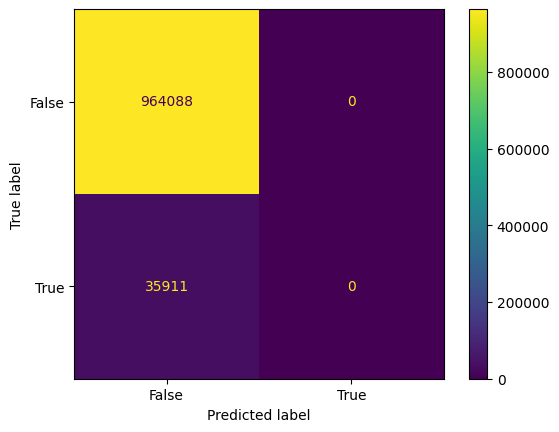

In [24]:
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test)

- All **fraudulent transactions are misclassified** as non-fraudulent.  
- The model perfectly identifies **non-fraudulent transactions**, but completely fails on the minority class.  
- This highlights the **severe impact of class imbalance**: the model defaults to predicting the majority class.  
- Accuracy is high (0.96), but it is **misleading**, as the model detects **no fraud cases**.  


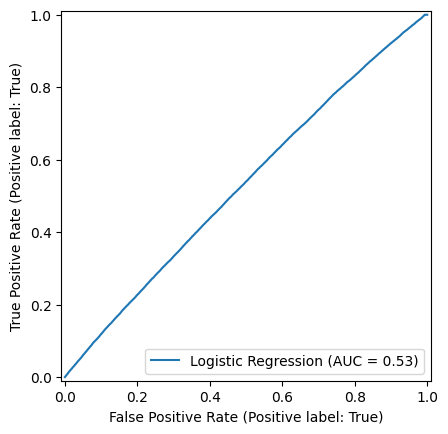

In [25]:
RocCurveDisplay.from_estimator(log_reg, X_test, y_test, name="Logistic Regression")

- **ROC AUC Score:** 0.53  
  - A ROC AUC of 0.53 indicates that the model is **barely better than random guessing** (0.5).  
  - The model struggles to distinguish between fraudulent and non-fraudulent transactions, likely due to the severe class imbalance.  

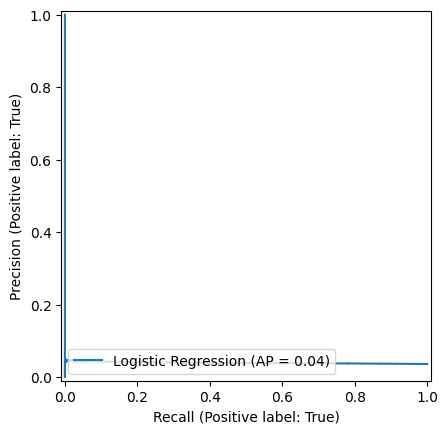

In [26]:
# precsion recall curve 
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(log_reg, X_test, y_test, name="Logistic Regression")


- **Average Precision (AP) Score:** 0.04  
  - An AP score of 0.04 is extremely low, confirming that the model **fails to correctly rank fraudulent transactions**.  
  - This metric emphasizes the model’s inability to capture the minority class, making it unsuitable for practical fraud detection.  

The evaluation of the first baseline model (**Logistic Regression**) reinforces our expectations: the model is severely impacted by **class imbalance** and performs very poorly on the minority (fraud) class.  

Consequently, we will definitely employ **special class imbalance handling techniques** in later experiments.  

For now, we will train the remaining three baseline models (**Random Forest**, **Extra Trees**, and **XGBoost**) to see if their performance on the minority class improves.

### Random Forest Classifier

In [46]:
# Since the Random Forest Classifier is invariant to feature scaling, we can use the preprocessing pipeline without the StandardScaler for it.
rf_clf = make_pipeline(
    preprocessing_without_scaling,
    to_float, 
    RandomForestClassifier(
    n_estimators=50, 
    max_depth=15,           # more depth to capture complex patterns
    max_features="log2",    # checks fewer features per split (faster than "sqrt")
    min_samples_leaf=100,   # prevents overly granular, slow splits      
    n_jobs=-1,              # uses all cores
    random_state=42
)
)

In [48]:
rf_clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [49]:
joblib.dump(rf_clf, '../src/models/rf_clf_baseline_model.joblib', compress=3)

['../src/models/rf_clf_baseline_model.joblib']

In [50]:
y_pred = rf_clf.predict(X_test)

In [51]:
print(classification_report(y_test, y_pred))

c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       False       0.96      1.00      0.98    964088
        True       0.00      0.00      0.00     35911

    accuracy                           0.96    999999
   macro avg       0.48      0.50      0.49    999999
weighted avg       0.93      0.96      0.95    999999



c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


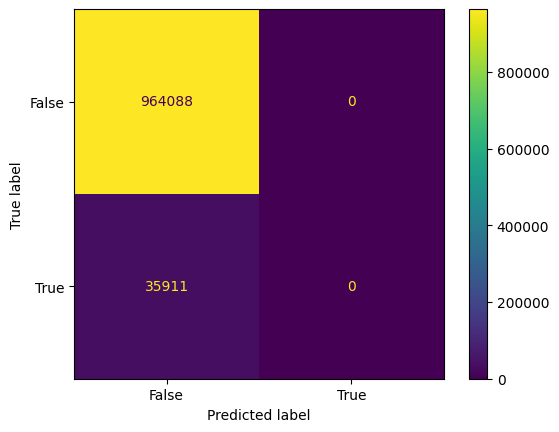

In [52]:
ConfusionMatrixDisplay.from_estimator(rf_clf, X_test, y_test)

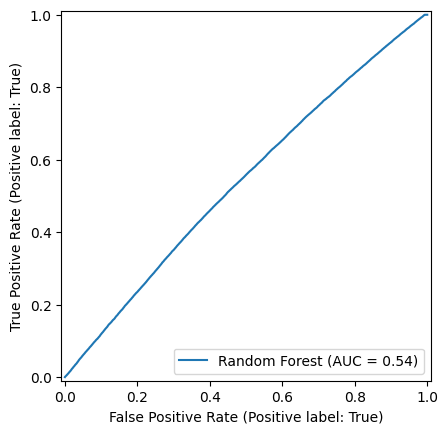

In [53]:
RocCurveDisplay.from_estimator(rf_clf, X_test, y_test, name="Random Forest")

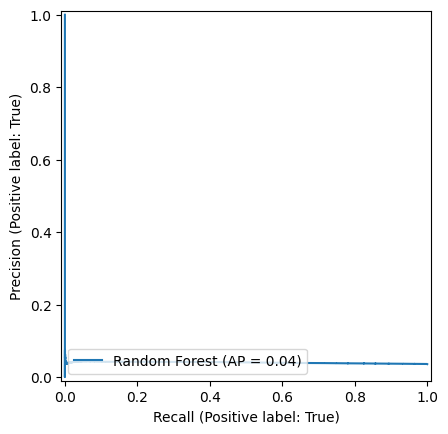

In [54]:
PrecisionRecallDisplay.from_estimator(rf_clf, X_test, y_test, name="Random Forest")

### Extremely Randomized Trees Classifier


In [59]:
extra_trees_clf = make_pipeline(
    preprocessing_without_scaling,
    to_float, 
    ExtraTreesClassifier(
        n_estimators=50,
        max_depth=15,
        max_features="log2",
        min_samples_leaf=100,
        n_jobs=-1,
        random_state=42
    )
)

In [60]:
extra_trees_clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [61]:
joblib.dump(extra_trees_clf, '../src/models/extra_trees_clf_baseline_model.joblib', compress=3)

['../src/models/extra_trees_clf_baseline_model.joblib']

### XGBoost Classifier

In [62]:
xgb_clf = make_pipeline(
    preprocessing_without_scaling,
    to_float, 
    xgb.XGBClassifier(
        n_estimators=50,
        max_depth=15,
        learning_rate=0.1,
        tree_method='hist',        # Essential: Histogram-based algorithm for speed
        max_bin=256,               # Standard binning for histograms
        min_child_weight=100,  
        n_jobs=-1,
        random_state=42,
        verbosity=1
    )
)

In [63]:
xgb_clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [64]:
joblib.dump(xgb_clf, '../src/models/xgb_clf_baseline_model.joblib', compress=3)

['../src/models/xgb_clf_baseline_model.joblib']